In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# Task 1

torch.manual_seed(42)  
np.random.seed(42)

WINDOW_SIZE = 96    # 96 samples = 24 hours (15-minute intervals)
BATCH_SIZE = 256

train_df = pd.read_csv("electricity_train.csv")
test_df = pd.read_csv("electricity_test.csv")

train_series = train_df["consumption"].values.astype(np.float32)
test_series = test_df["consumption"].values.astype(np.float32)

def create_windows(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i + window_size])
        y.append(series[i + window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_windows(train_series, WINDOW_SIZE)
X_test, y_test = create_windows(test_series, WINDOW_SIZE)

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train).unsqueeze(1)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class OneLinearLayerNN(nn.Module):
    def __init__(self, window_size):
        super().__init__()
        self.linear = nn.Linear(window_size, 1)

    def forward(self, x):
        return self.linear(x)

model_q1 = OneLinearLayerNN(WINDOW_SIZE)

print("Task 1 model:")
print(model_q1)
print()

print("Training windows shape:", X_train_tensor.shape)
print("Training targets shape:", y_train_tensor.shape)
print("Test windows shape:", X_test_tensor.shape)
print("Test targets shape:", y_test_tensor.shape)

# Check one forward pass on a small batch
sample_batch = X_train_tensor[:5]
sample_output = model_q1(sample_batch)

print()
print("Sample input batch shape:", sample_batch.shape)
print("Sample output shape:", sample_output.shape)
print("Sample predictions:")
print(sample_output.detach().numpy())

Task 1 model:
OneLinearLayerNN(
  (linear): Linear(in_features=96, out_features=1, bias=True)
)

Training windows shape: torch.Size([105119, 96])
Training targets shape: torch.Size([105119, 1])
Test windows shape: torch.Size([34944, 96])
Test targets shape: torch.Size([34944, 1])

Sample input batch shape: torch.Size([5, 96])
Sample output shape: torch.Size([5, 1])
Sample predictions:
[[-0.23527217]
 [-0.2669963 ]
 [-0.26473463]
 [-0.28820717]
 [-0.28321946]]


In [3]:
# Task 2

HIDDEN_1 = 64
HIDDEN_2 = 32

class TwoHiddenLayersNN(nn.Module):
    def __init__(self, window_size, hidden_1, hidden_2):
        super().__init__()
        self.fc1 = nn.Linear(window_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

torch.manual_seed(42)
model_q2 = TwoHiddenLayersNN(WINDOW_SIZE, HIDDEN_1, HIDDEN_2)

print("Task 2 model:")
print(model_q2)
print()

sample_batch = X_train_tensor[:5]
sample_output = model_q2(sample_batch)

print("Sample input batch shape:", sample_batch.shape)
print("Sample output shape:", sample_output.shape)
print("Sample predictions:")
print(sample_output.detach().numpy())

Task 2 model:
TwoHiddenLayersNN(
  (fc1): Linear(in_features=96, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Sample input batch shape: torch.Size([5, 96])
Sample output shape: torch.Size([5, 1])
Sample predictions:
[[0.5318743 ]
 [0.5252785 ]
 [0.5193336 ]
 [0.51648325]
 [0.51865834]]


In [4]:
# Task 3

class TwoHiddenLayersReLU(nn.Module):
    def __init__(self, window_size, hidden_1, hidden_2):
        super().__init__()
        self.fc1 = nn.Linear(window_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, 1)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        
        x = self.fc3(x)
        return x

torch.manual_seed(42)
model_q3 = TwoHiddenLayersReLU(WINDOW_SIZE, HIDDEN_1, HIDDEN_2)

print("Task 3 model:")
print(model_q3)
print()

sample_batch = X_train_tensor[:5]
sample_output = model_q3(sample_batch)

print("Sample input batch shape:", sample_batch.shape)
print("Sample output shape:", sample_output.shape)
print("Sample predictions:")
print(sample_output.detach().numpy())

Task 3 model:
TwoHiddenLayersReLU(
  (fc1): Linear(in_features=96, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Sample input batch shape: torch.Size([5, 96])
Sample output shape: torch.Size([5, 1])
Sample predictions:
[[0.24074976]
 [0.24309571]
 [0.24035731]
 [0.23559996]
 [0.23799708]]


In [5]:
# Task 4

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_q3.parameters(), lr=0.001)

torch.manual_seed(42)

X_batch, y_batch = next(iter(train_loader))

predictions = model_q3(X_batch)

loss = criterion(predictions, y_batch)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("Batch input shape:", X_batch.shape)
print("Batch target shape:", y_batch.shape)
print("Batch prediction shape:", predictions.shape)
print("MSE loss on one batch:", loss.item())

print()
print("Gradient check:")
print("fc1 weight grad shape:", model_q3.fc1.weight.grad.shape)
print("fc2 weight grad shape:", model_q3.fc2.weight.grad.shape)
print("fc3 weight grad shape:", model_q3.fc3.weight.grad.shape)

Batch input shape: torch.Size([256, 96])
Batch target shape: torch.Size([256, 1])
Batch prediction shape: torch.Size([256, 1])
MSE loss on one batch: 1.3515688180923462

Gradient check:
fc1 weight grad shape: torch.Size([64, 96])
fc2 weight grad shape: torch.Size([32, 64])
fc3 weight grad shape: torch.Size([1, 32])


In [6]:
# Task 5

torch.manual_seed(42)
model_q5 = TwoHiddenLayersReLU(WINDOW_SIZE, HIDDEN_1, HIDDEN_2)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_q5.parameters(), lr=0.001)

num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model_q5.train()
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        predictions = model_q5(X_batch)
        loss = criterion(predictions, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Average Train Loss: {avg_epoch_loss:.6f}")

print()
print("Train losses per epoch:")
print(train_losses)

Epoch 1/5, Average Train Loss: 0.128316
Epoch 2/5, Average Train Loss: 0.044748
Epoch 3/5, Average Train Loss: 0.040042
Epoch 4/5, Average Train Loss: 0.038107
Epoch 5/5, Average Train Loss: 0.036367

Train losses per epoch:
[0.12831575108506238, 0.04474756089005157, 0.04004219336403475, 0.03810736532447692, 0.03636710065895116]


In [8]:
# Task 6

model_q5.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        predictions = model_q5(X_batch)
        all_predictions.append(predictions)
        all_targets.append(y_batch)

all_predictions = torch.cat(all_predictions, dim=0)
all_targets = torch.cat(all_targets, dim=0)

y_pred = all_predictions.cpu().numpy().flatten()
y_true = all_targets.cpu().numpy().flatten()

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

# Avoid division by zero in MAPE
epsilon = 1e-8
mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

print("Task 6 evaluation on test set:")
print(f"MAE  = {mae:.6f}")
print(f"RMSE = {rmse:.6f}")
print(f"MAPE = {mape:.2f}%")

print("\nInterpretation:")
print("MAE and RMSE show good prediction accuracy")
print("MAPE is higher due to small true values in normalized data")

Task 6 evaluation on test set:
MAE  = 0.121348
RMSE = 0.200841
MAPE = 80.61%

Interpretation:
MAE and RMSE show good prediction accuracy
MAPE is higher due to small true values in normalized data


In [9]:
# Task 7

hidden1_values = [64, 128]
hidden2_values = [32, 64]
lr_values = [1e-3, 3e-4]
batch_values = [256, 512]

num_epochs = 3

results = []
best_mae = float("inf")
best_model = None
best_params = None

for hidden1 in hidden1_values:
    for hidden2 in hidden2_values:
        for lr in lr_values:
            for batch_size in batch_values:
                train_loader_tune = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                test_loader_tune = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

                torch.manual_seed(42)
                model = TwoHiddenLayersReLU(WINDOW_SIZE, hidden1, hidden2)

                criterion = nn.MSELoss()
                optimizer = torch.optim.Adam(model.parameters(), lr=lr)

                for epoch in range(num_epochs):
                    model.train()
                    for X_batch, y_batch in train_loader_tune:
                        predictions = model(X_batch)
                        loss = criterion(predictions, y_batch)

                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                model.eval()
                all_predictions = []
                all_targets = []

                with torch.no_grad():
                    for X_batch, y_batch in test_loader_tune:
                        predictions = model(X_batch)
                        all_predictions.append(predictions)
                        all_targets.append(y_batch)

                all_predictions = torch.cat(all_predictions, dim=0)
                all_targets = torch.cat(all_targets, dim=0)

                y_pred = all_predictions.cpu().numpy().flatten()
                y_true = all_targets.cpu().numpy().flatten()

                mae = np.mean(np.abs(y_true - y_pred))

                results.append({
                    "hidden1": hidden1,
                    "hidden2": hidden2,
                    "lr": lr,
                    "batch_size": batch_size,
                    "mae": mae
                })

                print(f"hidden1={hidden1}, hidden2={hidden2}, lr={lr}, batch={batch_size}, MAE={mae:.6f}")

                if mae < best_mae:
                    best_mae = mae
                    best_model = model
                    best_params = {
                        "hidden1": hidden1,
                        "hidden2": hidden2,
                        "lr": lr,
                        "batch_size": batch_size
                    }

print("\nBest configuration:")
print(best_params)
print(f"Best test MAE: {best_mae:.6f}")

results_df = pd.DataFrame(results).sort_values(by="mae").reset_index(drop=True)

print("\nAll results sorted by MAE:")
print(results_df)

hidden1=64, hidden2=32, lr=0.001, batch=256, MAE=0.125830
hidden1=64, hidden2=32, lr=0.001, batch=512, MAE=0.123875
hidden1=64, hidden2=32, lr=0.0003, batch=256, MAE=0.126572
hidden1=64, hidden2=32, lr=0.0003, batch=512, MAE=0.149345
hidden1=64, hidden2=64, lr=0.001, batch=256, MAE=0.133128
hidden1=64, hidden2=64, lr=0.001, batch=512, MAE=0.127239
hidden1=64, hidden2=64, lr=0.0003, batch=256, MAE=0.130244
hidden1=64, hidden2=64, lr=0.0003, batch=512, MAE=0.149613
hidden1=128, hidden2=32, lr=0.001, batch=256, MAE=0.120209
hidden1=128, hidden2=32, lr=0.001, batch=512, MAE=0.123571
hidden1=128, hidden2=32, lr=0.0003, batch=256, MAE=0.125239
hidden1=128, hidden2=32, lr=0.0003, batch=512, MAE=0.135500
hidden1=128, hidden2=64, lr=0.001, batch=256, MAE=0.123569
hidden1=128, hidden2=64, lr=0.001, batch=512, MAE=0.121172
hidden1=128, hidden2=64, lr=0.0003, batch=256, MAE=0.127393
hidden1=128, hidden2=64, lr=0.0003, batch=512, MAE=0.137400

Best configuration:
{'hidden1': 128, 'hidden2': 32, 'lr

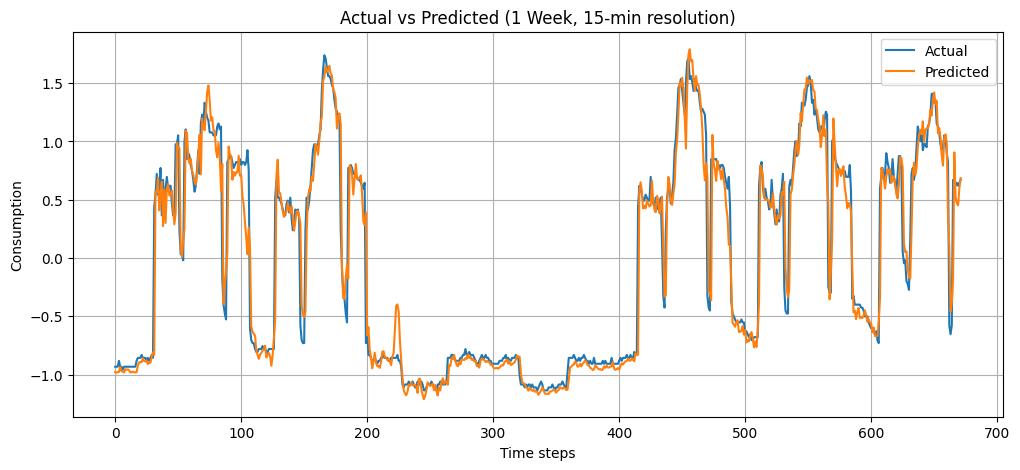

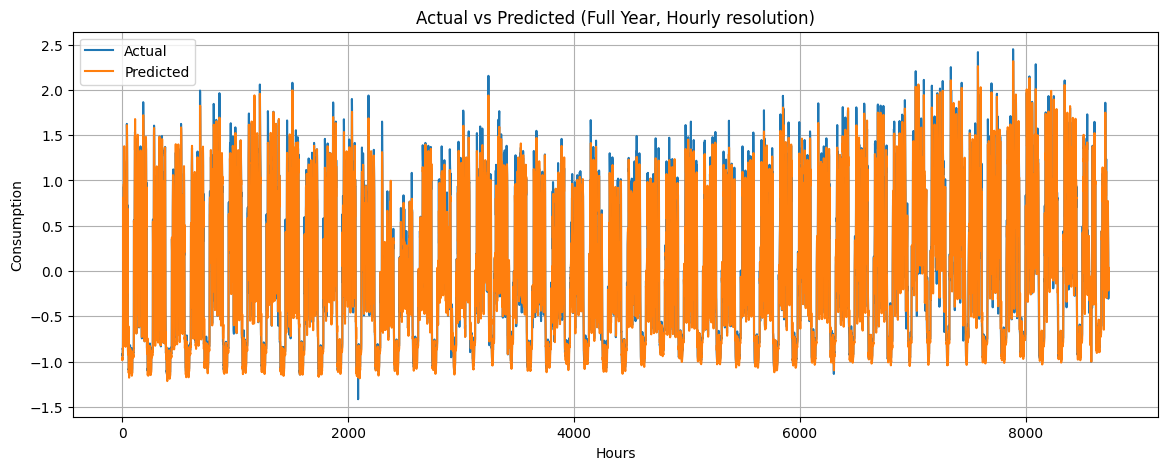


Observation:
The predicted values follow the actual trend quite well
The model captures the overall pattern, but some peaks are slightly smoothed


In [10]:
# Task 8

import matplotlib.pyplot as plt

best_model.eval()

all_predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        preds = best_model(X_batch)
        all_predictions.append(preds)

all_predictions = torch.cat(all_predictions, dim=0).cpu().numpy().flatten()
y_true = y_test_tensor.cpu().numpy().flatten()

# a) One Week (15-min resolution)

points_per_week = 7 * 24 * 4  # 7 days, 24h, 4 points per hour
start = 0
end = points_per_week

plt.figure(figsize=(12, 5))
plt.plot(y_true[start:end], label="Actual")
plt.plot(all_predictions[start:end], label="Predicted")
plt.title("Actual vs Predicted (1 Week, 15-min resolution)")
plt.xlabel("Time steps")
plt.ylabel("Consumption")
plt.legend()
plt.grid()
plt.show()

# b) Full Year (hourly resolution)

# reshape to hourly (4 values -> 1 hour)
def to_hourly(series):
    length = (len(series) // 4) * 4 
    return series[:length].reshape(-1, 4).mean(axis=1)

y_true_hourly = to_hourly(y_true)
y_pred_hourly = to_hourly(all_predictions)

plt.figure(figsize=(14, 5))
plt.plot(y_true_hourly, label="Actual")
plt.plot(y_pred_hourly, label="Predicted")
plt.title("Actual vs Predicted (Full Year, Hourly resolution)")
plt.xlabel("Hours")
plt.ylabel("Consumption")
plt.legend()
plt.grid()
plt.show()

print("\nObservation:")
print("The predicted values follow the actual trend quite well")
print("The model captures the overall pattern, but some peaks are slightly smoothed")

In [11]:
# Task 9

best_model.eval()

# Number of 15-minute steps in one non-leap year
forecast_steps = 365 * 24 * 4  

last_window = test_series[-WINDOW_SIZE:].copy()

forecast_2015 = []

with torch.no_grad():
    current_window = last_window.copy()

    for _ in range(forecast_steps):
        x_input = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0)

        next_value = best_model(x_input).item()

        forecast_2015.append(next_value)

        current_window = np.append(current_window[1:], next_value)

forecast_2015 = np.array(forecast_2015, dtype=np.float32)

forecast_index_2015 = pd.date_range(
    start="2015-01-01 00:00:00",
    periods=forecast_steps,
    freq="15min"
)

forecast_2015_df = pd.DataFrame({
    "timestamp": forecast_index_2015,
    "forecast_consumption": forecast_2015
})

print("Task 9 - 2015 forecast created successfully")
print("Forecast shape:", forecast_2015.shape)
print("Forecast covers the full year 2015 at 15-minute intervals")
print()

print("First 5 forecast values:")
print(forecast_2015[:5])
print()

print("Last 5 forecast values:")
print(forecast_2015[-5:])
print()

print("Forecast DataFrame preview:")
print(forecast_2015_df.head())
print()

print("Note: This forecast is generated recursively, so small errors can accumulate over time")

Task 9 - 2015 forecast created successfully
Forecast shape: (35040,)
Forecast covers the full year 2015 at 15-minute intervals

First 5 forecast values:
[0.00815562 0.0769923  0.15882796 0.21284464 0.27317083]

Last 5 forecast values:
[-1.4301358 -1.4218562 -1.41261   -1.4024628 -1.3914795]

Forecast DataFrame preview:
            timestamp  forecast_consumption
0 2015-01-01 00:00:00              0.008156
1 2015-01-01 00:15:00              0.076992
2 2015-01-01 00:30:00              0.158828
3 2015-01-01 00:45:00              0.212845
4 2015-01-01 01:00:00              0.273171

Note: This forecast is generated recursively, so small errors can accumulate over time


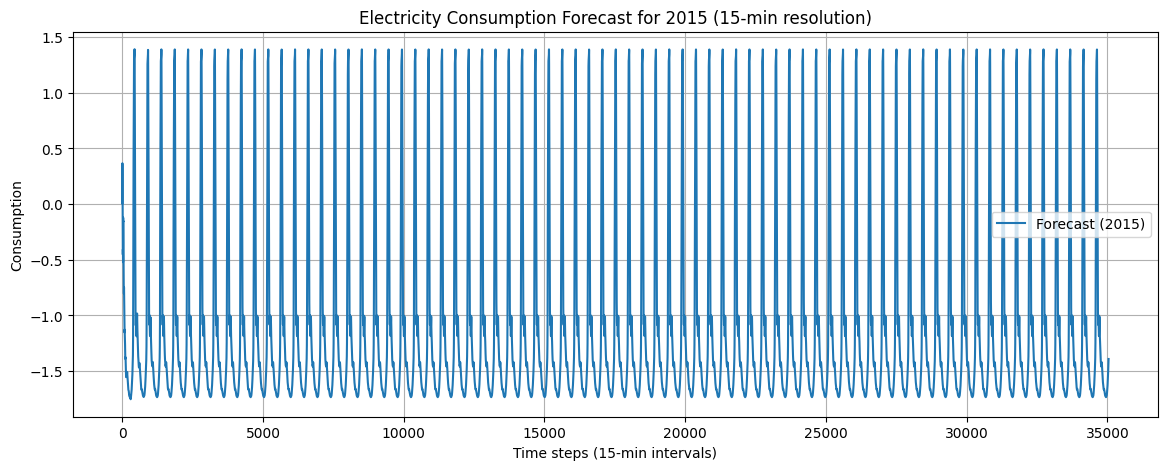

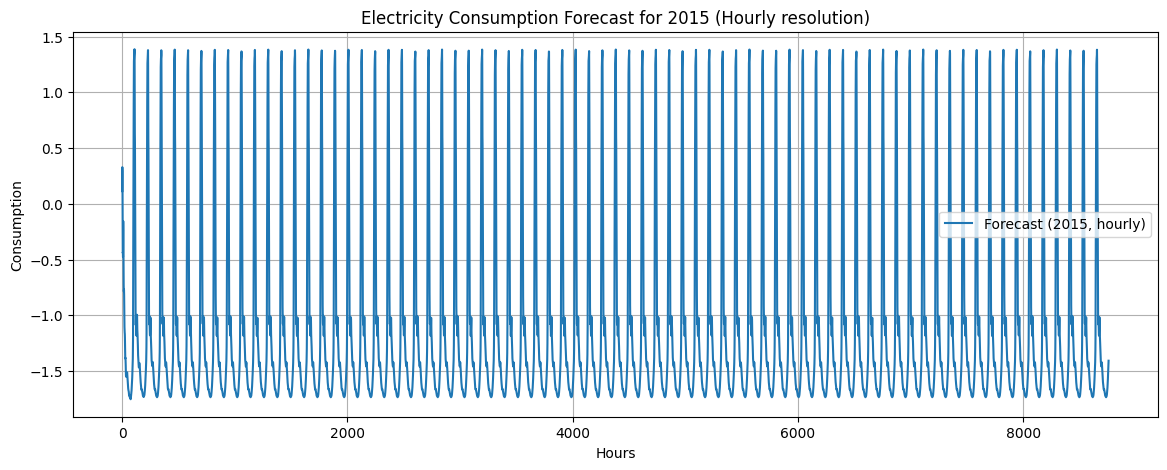


Observation:
The 2015 forecast shows a very repetitive pattern across the year
This suggests that recursive forecasting can accumulate error and drift into an artificial cycle


In [12]:
# Task 10

import matplotlib.pyplot as plt

# a) Full year (15-min resolution)
plt.figure(figsize=(14, 5))
plt.plot(forecast_2015, label="Forecast (2015)")
plt.title("Electricity Consumption Forecast for 2015 (15-min resolution)")
plt.xlabel("Time steps (15-min intervals)")
plt.ylabel("Consumption")
plt.legend()
plt.grid()
plt.show()

# b) Hourly resolution view
def to_hourly(series):
    length = (len(series) // 4) * 4
    return series[:length].reshape(-1, 4).mean(axis=1)

forecast_hourly = to_hourly(forecast_2015)

plt.figure(figsize=(14, 5))
plt.plot(forecast_hourly, label="Forecast (2015, hourly)")
plt.title("Electricity Consumption Forecast for 2015 (Hourly resolution)")
plt.xlabel("Hours")
plt.ylabel("Consumption")
plt.legend()
plt.grid()
plt.show()

print("\nObservation:")
print("The 2015 forecast shows a very repetitive pattern across the year")
print("This suggests that recursive forecasting can accumulate error and drift into an artificial cycle")